# Manifest stats (splits)


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
MANIFEST_DIR = DATA_DIR / "manifests"
EXPORT_DIR = PROJECT_ROOT / "notebooks" / "data" / "manifest-stats"

TASKS = {
    "trick-classification": {
        "dir": "trick_classification",
        "target": "trick",
    },
    "score-prediction": {
        "dir": "score_prediction",
        "target": "execution_score",
    },
}

EXPORT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
def load_task_manifest(task_dir):
    split_paths = {
        "train": task_dir / "train.jsonl",
        "val": task_dir / "val.jsonl",
        "test": task_dir / "test.jsonl",
    }
    split_frames = {}
    for split, path in split_paths.items():
        if not path.exists():
            raise FileNotFoundError(
                f"Missing manifest: {path}. Run the data pipeline first."
            )
        df = pd.read_json(path, lines=True)
        df["split"] = split
        split_frames[split] = df

    manifest_df = pd.concat(split_frames.values(), ignore_index=True)
    return manifest_df, split_frames


In [3]:
task_manifests = {}
for task_name, task_cfg in TASKS.items():
    task_dir = MANIFEST_DIR / task_cfg["dir"]
    manifest_df, split_frames = load_task_manifest(task_dir)
    task_manifests[task_name] = {
        "manifest_df": manifest_df,
        "split_frames": split_frames,
    }

    print(f"Task: {task_name}")
    print("Rows per split:")
    for split, df in split_frames.items():
        print(f"  {split}: {len(df)}")
    print("Target counts (all):")
    print(manifest_df[task_cfg["target"]].value_counts())
    print()


Task: trick-classification
Rows per split:
  train: 455
  val: 58
  test: 57
Target counts (all):
trick
bs-royale     93
fs-savanah    86
soul          83
ao-soul       80
fs-royale     80
mizou         75
top-soul      73
Name: count, dtype: int64

Task: score-prediction
Rows per split:
  train: 455
  val: 58
  test: 57
Target counts (all):
execution_score
0.75    219
0.50    166
1.00    161
0.25     24
Name: count, dtype: int64



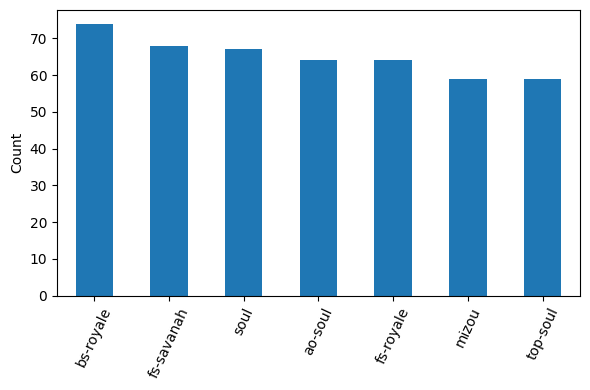

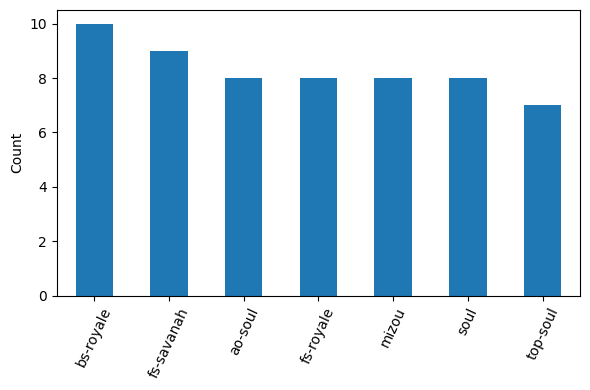

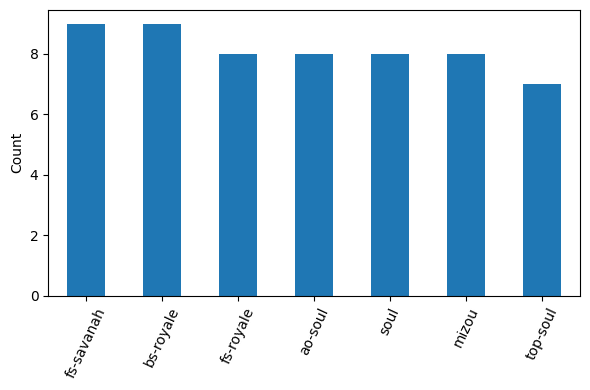

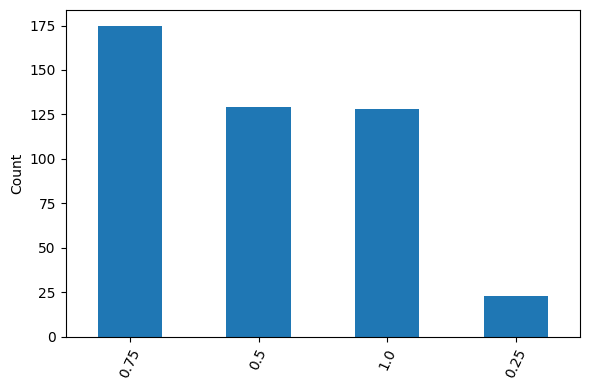

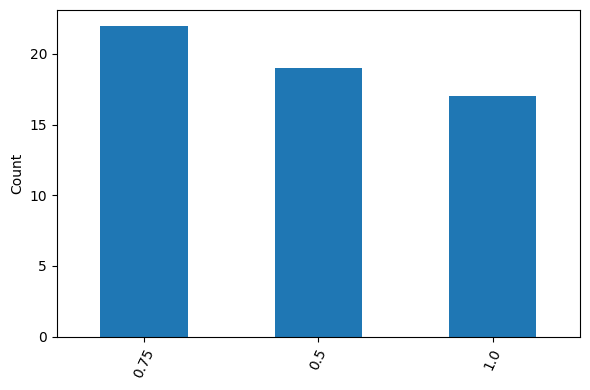

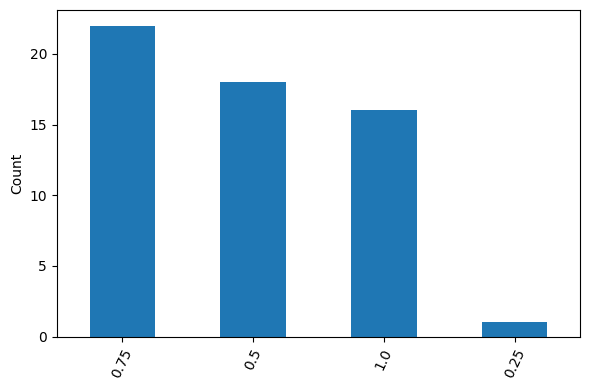

In [4]:
for task_name, task_cfg in TASKS.items():
    split_frames = task_manifests[task_name]["split_frames"]
    target_col = task_cfg["target"]

    task_export_dir = EXPORT_DIR / task_name
    task_export_dir.mkdir(parents=True, exist_ok=True)

    for split in ["train", "val", "test"]:
        df = split_frames[split]
        counts = df[target_col].value_counts().sort_values(ascending=False)

        fig, ax = plt.subplots(figsize=(6, 4))
        counts.plot(kind="bar", ax=ax)
        ax.set_xlabel("")
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=65)

        fig.tight_layout()
        fig.savefig(task_export_dir / f"{split}-dist.png")
        plt.show()
